# Algoritmos

## Gerando dados

In [1]:
from joblib import dump, load

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np


In [2]:
df_10 = load('./data/05_aula_df_10')
df_10.head()

,indep_1,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,k_means,DBSCAN_1,DBSCAN_2,NN_k_means,k_NN,log_reg,SVM,dec_tree,random_forest,gbm,nb,NN
53,41,24.36,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0
93,9,8.05,0,1,0,1,0,0,1,1,1,0,0,1,0,0,0,0,0,0
20,36,19.92,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
177,13,7.73,1,0,1,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0
26,17,6.21,1,0,1,0,0,0,1,1,1,0,0,1,0,0,0,0,0,0


In [3]:
df_reg = df_10.iloc[:, [0, 1, 2, 3, 4, 5, 6]].copy()
df_reg['target'] = df_10['indep_1']
df_reg.drop(columns=['indep_1'], inplace=True)
df_reg.head() 

,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target
53,24.36,1,0,0,0,1,41
93,8.05,0,1,0,1,0,9
20,19.92,1,0,0,0,1,36
177,7.73,1,0,1,0,0,13
26,6.21,1,0,1,0,0,17


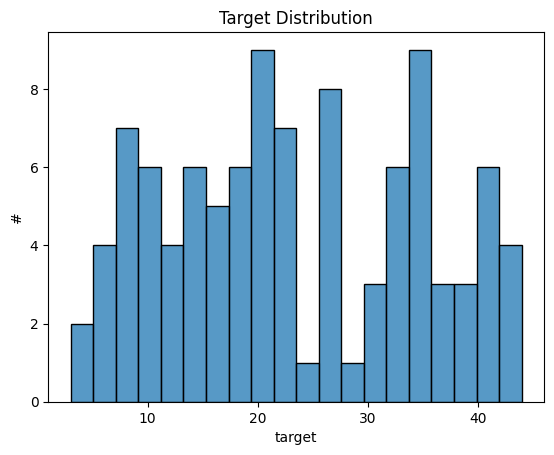

In [4]:
sns.histplot(
    x='target',
    bins=20,
    data=df_reg,
)
plt.title('Target Distribution')
plt.xlabel('target')
plt.ylabel('#')
plt.show()

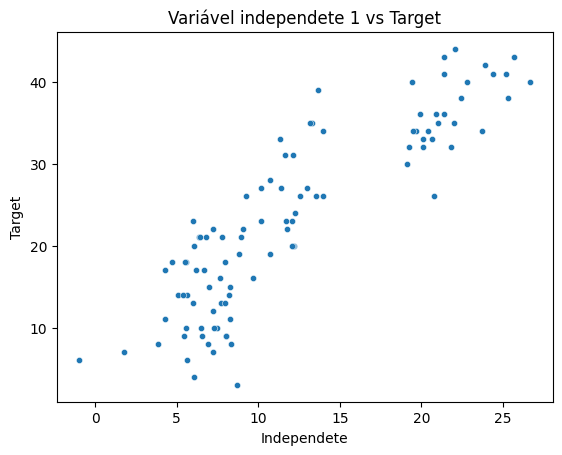

In [5]:
sns.scatterplot(
    x='indep_2',
    y='target',
    s=20,
    data=df_reg,
)
plt.title('Variável independete 1 vs Target')
plt.xlabel('Independete')
plt.ylabel('Target')
plt.show()

## Regressão Linear Simples                                                                                             

In [6]:
from src.line_equation import Line_equation
import statsmodels.formula.api as smf
import numpy as np

from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [7]:
def train_test_df(df: pd.DataFrame) -> tuple:
    '''    Função que divide o DataFrame em treino e teste
    '''
    index = df.sample(frac=0.3, random_state=42).index
    df_train = df.loc[[i for i in df.index if i not in index], :]
    df_test = df.loc[index, :]

    print(f"df_train: {df_train.shape}")
    print(f"df_test: {df_test.shape}")

    return df_train, df_test

In [8]:
def train_test_df_split(df: pd.DataFrame, indep: list, target: str = "target") -> tuple:
    '''
        Função que divide o DataFrame em treino e teste
    '''
    df_train, df_test = train_test_df(df)

    X_train = df_train.loc[:, indep].copy()
    X_test = df_test.loc[:, indep].copy()

    y_train = df_train.loc[:, target].copy()
    y_test = df_test.loc[:, target].copy()

    print(f"X_train: {X_train.shape}")
    print(f"X_test: {X_test.shape}")
    print(f"y_train: {y_train.shape}")
    print(f"y_test: {y_test.shape}")

    return df_train, df_test, X_train, X_test, y_train, y_test

In [9]:
df_reg.head()

,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target
53,24.36,1,0,0,0,1,41
93,8.05,0,1,0,1,0,9
20,19.92,1,0,0,0,1,36
177,7.73,1,0,1,0,0,13
26,6.21,1,0,1,0,0,17


In [10]:
indep = df_reg.columns[[0, 1, 2, 3, 4, 5]]
df_reg_train, df_reg_test, X_test, X_train, y_test, y_train = train_test_df_split(df=df_reg, indep=indep)

df_train: (70, 7)
df_test: (30, 7)
X_train: (70, 6)
X_test: (30, 6)
y_train: (70,)
y_test: (30,)


In [11]:
modelo = '''
                target ~ 
                indep_2
        '''
reg_simpl = smf.ols(modelo, data=df_reg_train).fit()
reg_simpl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     207.4
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           2.47e-22
Time:                        19:20:14   Log-Likelihood:                -218.34
No. Observations:                  70   AIC:                             440.7
Df Residuals:                      68   BIC:                             445.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.5752      1.438      3.877      0.000       2.706       8.445
indep_2        1.4859      0.103     14.400      0.000       1.280       1.692
==============================================================================
Omnibus:                        0.089   Durbin-Watson:                   1.707
Prob(Omnibus):                  0.956   Jarque-Bera (JB):                0.015
Skew:                          -0.027   Prob(JB):                        0.993
Kurtosis:                       2.954   Cond. No.                         30.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [12]:
df_4_copy = df_reg_train.copy()
curva = Line_equation(
    dados=df_4_copy.loc[:, ['indep_2', 'target']],
    coluna_x='indep_2',
    coluna_y='target',
)
df_4_copy.head()

,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target
93,8.05,0,1,0,1,0,9
20,19.92,1,0,0,0,1,36
177,7.73,1,0,1,0,0,13
0,6.37,0,1,1,0,0,21
154,22.80,1,0,0,0,1,40


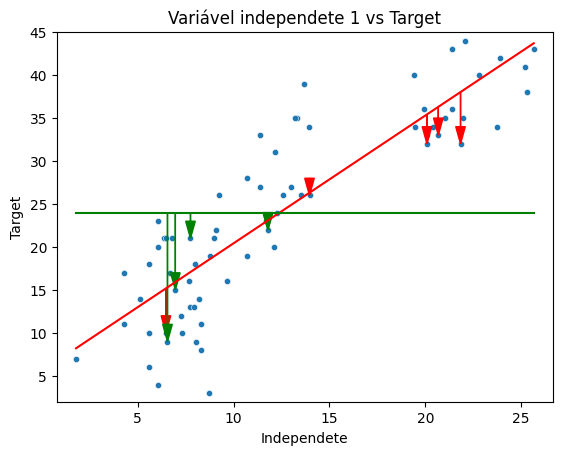

In [13]:
sns.scatterplot(
    x='indep_2',
    y='target',
    s=20,
    data=df_4_copy
)

dados_reta = [reg_simpl.params[0], reg_simpl.params[1]]
df_4_copy['target_cal'] = df_4_copy['indep_2'].apply(curva.reta, args=dados_reta)
sns.lineplot(
    x='indep_2',
    y='target_cal',
    data=df_4_copy,
    c='r',
)
for n in range(5):
    index = df_4_copy['indep_2'].sample(1).index[0]
    x = df_4_copy['indep_2'][index]
    y = df_4_copy['target_cal'][index]
    d = df_4_copy['target'][index] - y

    plt.arrow(
        x,
        y,
        0,
        d,
        head_width=.5,
        head_length=2,
        length_includes_head=True,
        color='r',
    )

dados_reta = [df_4_copy['target'].mean(), 0]
df_4_copy['target_media'] = df_4_copy['indep_2'].apply(curva.reta, args=dados_reta)
sns.lineplot(
    x='indep_2',
    y='target_media',
    data=df_4_copy,
    c='g',
)
for n in range(5):
    index = df_4_copy['indep_2'].sample(1).index[0]
    x = df_4_copy['indep_2'][index]
    y = df_4_copy['target_media'][index]
    d = df_4_copy['target'][index] - y

    plt.arrow(
        x,
        y,
        0,
        d,
        head_width=.5,
        head_length=2,
        length_includes_head=True,
        color='g',
    )

plt.title('Variável independete 1 vs Target')

plt.xlabel('Independete')
plt.xlim(df_4_copy['indep_2'].min()-1, df_4_copy['indep_2'].max()+1)

plt.ylabel('Target')
plt.ylim(df_4_copy['target'].min()-1, df_4_copy['target'].max()+1)

plt.show()

In [14]:
df_reg_test['linear_simples'] = reg_simpl.predict(df_reg_test['indep_2'])
df_reg_test.head()

,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples
132,5.53,0,1,1,0,0,18,13.792351
143,5.61,0,1,1,0,0,14,13.911224
121,5.37,0,1,1,0,0,14,13.554604
91,7.22,0,1,1,0,0,22,16.303549
74,12.19,0,1,0,1,0,20,23.688553


In [15]:
def r2_score(y_true, y_pred):
    """
    Calculates the coefficient of determination (R-squared) manually.

    Args:
        y_true (list or np.array): The true (observed) values.
        y_pred (list or np.array): The predicted values from the model.

    Returns:
        float: The R-squared value.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Calculate the mean of the true values
    y_true_mean = np.mean(y_true)

    # Calculate the Sum of Squares of Residuals (SS_res)
    ss_res = np.sum((y_true - y_pred) ** 2)

    # Calculate the Total Sum of Squares (SS_tot)
    ss_tot = np.sum((y_true - y_true_mean) ** 2)

    # Handle the case where SS_tot is zero (e.g., all y_true values are the same)
    if ss_tot == 0:
        return 1.0  # R-squared is 1 if there's no variance in y_true

    # Calculate R-squared
    r_squared = 1 - (ss_res / ss_tot)

    return r_squared

In [16]:
def metricas(
        y_true: pd.Series,
        y_pred: pd.Series,
        nome_modelo: str = None) -> None:
    '''
        Função que calcula as métricas de erro
    '''
    df_test = pd.DataFrame()
    df_test['y_true'] = y_true
    df_test['y_pred'] = y_pred

    r_cal, r_cal_p = spearmanr(df_test['y_true'], df_test['y_pred'])
    r2_cal = r2_score(df_test['y_true'], df_test['y_pred'])
    mae_cal = mean_absolute_error(df_test['y_true'], df_test['y_pred'])
    rmse_cal = mean_squared_error(df_test['y_true'], df_test['y_pred'])
    mape_cal = mean_absolute_percentage_error(
                                                    df_test['y_true'],
                                                    df_test['y_pred']
                                            )

    mensagem = f'''
R Spearman: {r_cal:.4f}
R p-value: {r_cal_p:.4f}
R2: {r2_cal:.4f}
MAE: {mae_cal:.4f}
RMSE: {rmse_cal:.4f}
MAPE: {mape_cal:.4f}
    '''
    
    p = sns.jointplot(
        x='y_true',
        y='y_pred',
        data=df_test,
        kind='reg',
    )
    p.fig.suptitle(f"Correlação predito / observado - {nome_modelo}", y=1.02)
    plt.text(
        0.05,
        0.99,
        mensagem,
        transform=p.ax_joint.transAxes,
        fontsize=12,
        ha='left',
        va='top'
    )
    plt.xlabel('Observado')
    plt.ylabel('Predito')
    plt.show()

    return None

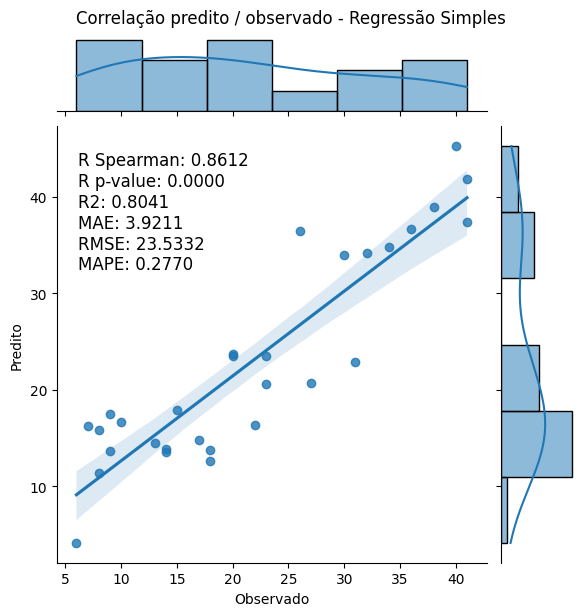

In [17]:
metricas(df_reg_test['target'], df_reg_test['linear_simples'], nome_modelo='Regressão Simples')

In [18]:
df_reg_test.head()

,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples
132,5.53,0,1,1,0,0,18,13.792351
143,5.61,0,1,1,0,0,14,13.911224
121,5.37,0,1,1,0,0,14,13.554604
91,7.22,0,1,1,0,0,22,16.303549
74,12.19,0,1,0,1,0,20,23.688553


## Regressão Linear Multipla

In [19]:
modelo = '''
                target ~ 
                indep_2 +
                indep_3_max +
                indep_3_min +
                indep_4_min +
                indep_4_med +
                indep_4_max
        '''
reg_mult = smf.ols(modelo, data=df_reg).fit()
reg_mult.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     88.08
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           4.19e-31
Time:                        19:20:15   Log-Likelihood:                -304.67
No. Observations:                 100   AIC:                             619.3
Df Residuals:                      95   BIC:                             632.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       5.1281      1.444      3.551      0.001       2.261       7.995
indep_2         1.1540      0.212      5.433      0.000       0.732       1.576
indep_3_max     3.7028      0.909      4.072      0.000       1.898       5.508
indep_3_min     1.4253      0.881      1.617      0.109      -0.324       3.175
indep_4_min    -0.8185      1.158     -0.707      0.481      -3.118       1.481
indep_4_med     1.5137      0.755      2.004      0.048       0.014       3.013
indep_4_max     4.4329      2.371      1.870      0.065      -0.274       9.140
==============================================================================
Omnibus:                        0.436   Durbin-Watson:                   1.771
Prob(Omnibus):                  0.804   Jarque-Bera (JB):                0.345
Skew:                          -0.143   Prob(JB):                        0.842
Kurtosis:                       2.961   Cond. No.                     1.94e+17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 5.13e-31. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [20]:
modelo = '''
                target ~ 
                indep_2 +
                indep_3_max +
                indep_4_med
        '''
reg_mult = smf.ols(modelo, data=df_reg).fit()
reg_mult.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.782
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                     115.0
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           1.16e-31
Time:                        19:20:15   Log-Likelihood:                -305.92
No. Observations:                 100   AIC:                             619.8
Df Residuals:                      96   BIC:                             630.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       4.3369      1.330      3.261      0.002       1.697       6.977
indep_2         1.4588      0.081     18.105      0.000       1.299       1.619
indep_3_max     2.2713      1.067      2.130      0.036       0.154       4.388
indep_4_med     0.6077      1.148      0.529      0.598      -1.672       2.887
==============================================================================
Omnibus:                        0.132   Durbin-Watson:                   1.785
Prob(Omnibus):                  0.936   Jarque-Bera (JB):                0.033
Skew:                          -0.044   Prob(JB):                        0.984
Kurtosis:                       2.994   Cond. No.                         41.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [21]:
df_reg_test['linear_multi'] = reg_mult.predict(df_reg_test[['indep_2','indep_3_max', 'indep_4_med']])
df_reg_test.head()

,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples,linear_multi
132,5.53,0,1,1,0,0,18,13.792351,12.404122
143,5.61,0,1,1,0,0,14,13.911224,12.520826
121,5.37,0,1,1,0,0,14,13.554604,12.170714
91,7.22,0,1,1,0,0,22,16.303549,14.869497
74,12.19,0,1,0,1,0,20,23.688553,22.727430


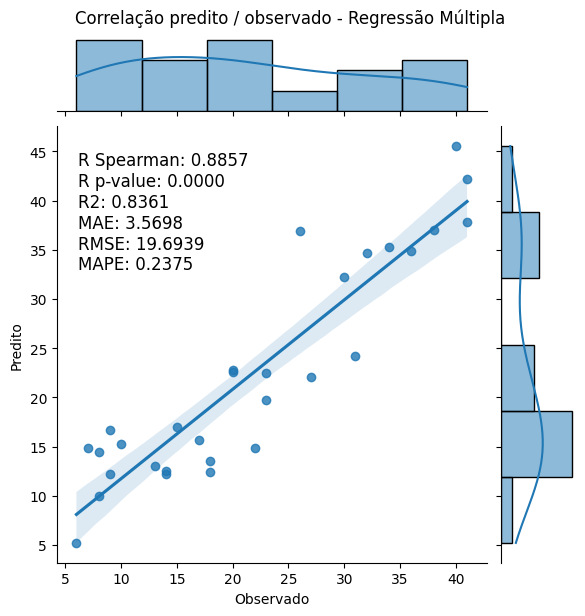

In [22]:
metricas(df_reg_test['target'], df_reg_test['linear_multi'], nome_modelo='Regressão Múltipla')

In [23]:
df_reg['linear_simples'] = reg_simpl.predict(df_reg['indep_2'])
df_reg['linear_multi'] = reg_mult.predict(df_reg[['indep_2', 'indep_3_max', 'indep_4_med']])
df_reg.head()

,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples,linear_multi
53,24.36,1,0,0,0,1,41,41.772154,42.144690
93,8.05,0,1,0,1,0,9,17.536860,16.687991
20,19.92,1,0,0,0,1,36,35.174686,35.667611
177,7.73,1,0,1,0,0,13,17.061367,17.884818
26,6.21,1,0,1,0,0,17,14.802774,15.667440


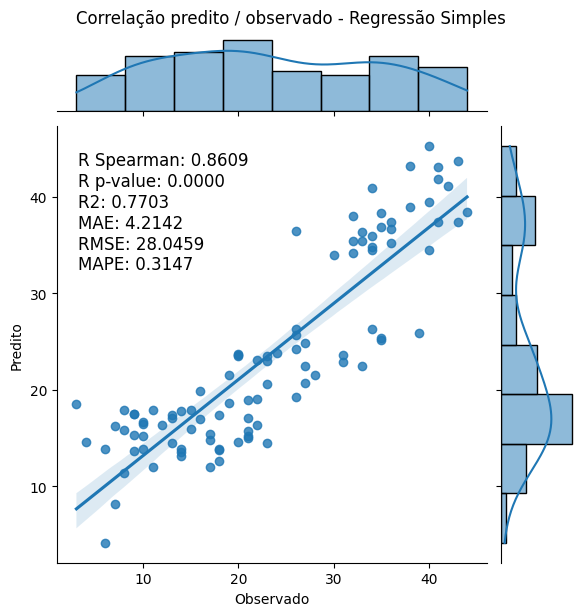

In [24]:
metricas(df_reg['target'], df_reg['linear_simples'], nome_modelo='Regressão Simples')

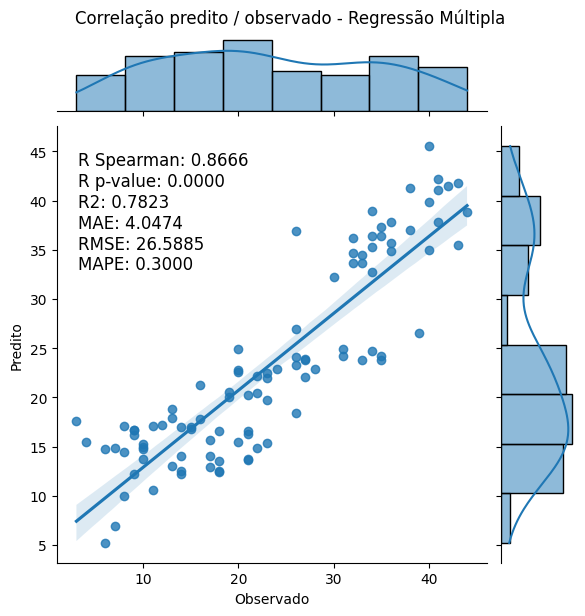

In [25]:
metricas(df_reg['target'], df_reg['linear_multi'], nome_modelo='Regressão Múltipla')

In [26]:
dump(df_reg, './data/05_aula_df_11')
df_12 = load('./data/05_aula_df_11')

df_12.head()

,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples,linear_multi
53,24.36,1,0,0,0,1,41,41.772154,42.144690
93,8.05,0,1,0,1,0,9,17.536860,16.687991
20,19.92,1,0,0,0,1,36,35.174686,35.667611
177,7.73,1,0,1,0,0,13,17.061367,17.884818
26,6.21,1,0,1,0,0,17,14.802774,15.667440


## SVM

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

In [28]:
df_reg_train, df_reg_test, X_test, X_train, y_test, y_train = train_test_df_split(df=df_12, indep=indep)

df_train: (70, 9)
df_test: (30, 9)
X_train: (70, 6)
X_test: (30, 6)
y_train: (70,)
y_test: (30,)


In [29]:
kernel = ['linear', 'poly', 'rbf', 'sigmoid']

svm = SVC()

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': kernel,
}

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=2,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)
grid_svm.best_params_

Fitting 2 folds for each of 64 candidates, totalling 128 fits


/usr/local/lib/python3.10/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


{'C': 0.1, 'gamma': 0.001, 'kernel': 'sigmoid'}

In [30]:
svm = SVC()
svm.set_params(**grid_svm.best_params_)
svm.fit(X_train, y_train)

svm.score(X_test, y_test)

0.04285714285714286

In [31]:
c = -3
df_reg_test['svm'] = svm.predict(df_reg_test[df_reg_test.columns[:c]])
df_reg_test.head()

,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples,linear_multi,svm
132,5.53,0,1,1,0,0,18,13.792351,12.404122,14
143,5.61,0,1,1,0,0,14,13.911224,12.520826,14
121,5.37,0,1,1,0,0,14,13.554604,12.170714,14
91,7.22,0,1,1,0,0,22,16.303549,14.869497,9
74,12.19,0,1,0,1,0,20,23.688553,22.727430,20


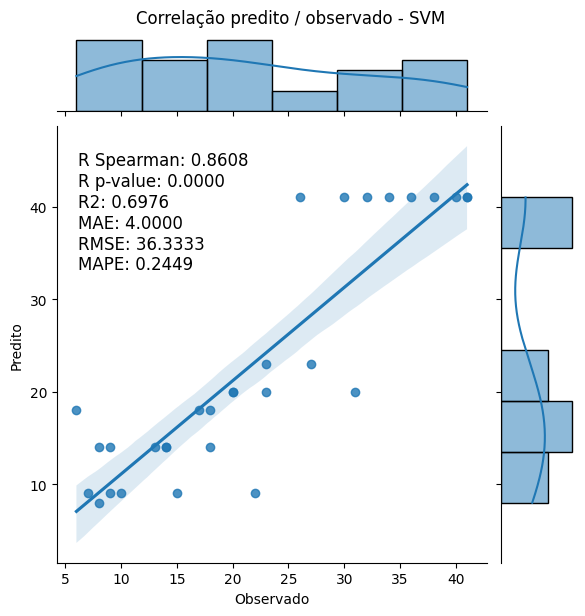

In [32]:
metricas(df_reg_test['target'], df_reg_test['svm'], nome_modelo='SVM')

In [33]:
df_12['svm'] = svm.predict(df_12[df_12.columns[:c]])
df_12.head()

,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples,linear_multi,svm
53,24.36,1,0,0,0,1,41,41.772154,42.144690,41
93,8.05,0,1,0,1,0,9,17.536860,16.687991,9
20,19.92,1,0,0,0,1,36,35.174686,35.667611,41
177,7.73,1,0,1,0,0,13,17.061367,17.884818,9
26,6.21,1,0,1,0,0,17,14.802774,15.667440,18


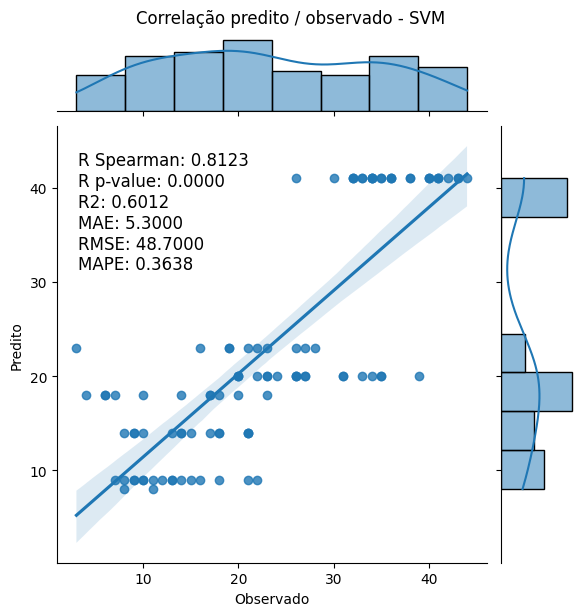

In [34]:
metricas(df_12['target'], df_12['svm'], nome_modelo='SVM')

In [35]:
dump(df_12, './data/05_aula_df_12')
df_13 = load('./data/05_aula_df_12')

df_13.head()

,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples,linear_multi,svm
53,24.36,1,0,0,0,1,41,41.772154,42.144690,41
93,8.05,0,1,0,1,0,9,17.536860,16.687991,9
20,19.92,1,0,0,0,1,36,35.174686,35.667611,41
177,7.73,1,0,1,0,0,13,17.061367,17.884818,9
26,6.21,1,0,1,0,0,17,14.802774,15.667440,18


## Naive Bayes

In [36]:
from sklearn.naive_bayes import MultinomialNB

In [37]:
df_13.describe()

,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples,linear_multi,svm
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,12.149100,0.440000,0.560000,0.340000,0.330000,0.330000,23.260000,23.627779,23.260000,23.120000
std,6.699893,0.498888,0.498888,0.476095,0.472582,0.472582,11.106118,9.955480,9.822869,11.991815
min,-0.960000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,4.148754,5.207832,8.000000
25%,6.875000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,15.790908,15.437679,14.000000
50%,10.155000,0.000000,1.000000,0.000000,0.000000,0.000000,22.000000,20.664714,20.930905,20.000000
75%,19.432500,1.000000,1.000000,1.000000,1.000000,1.000000,33.250000,34.450302,33.622393,41.000000
max,26.680000,1.000000,1.000000,1.000000,1.000000,1.000000,44.000000,45.219480,45.529110,41.000000


In [38]:
try:
    nb = MultinomialNB()

    parametros = {
        'alpha' : [1.0, 0.5, 0.1, 0.01],
        'fit_prior': [True, False],
    }

    grid_nb = GridSearchCV(
                            estimator=nb,
                            param_grid=parametros,
                            scoring='r2',
                            verbose=False,
                            cv=2
    ).fit(X_train, y_train)

    grid_nb.best_params_
except Exception as e:
    print(f"Erro ao treinar o modelo: {e}")

Erro ao treinar o modelo: Negative values in data passed to MultinomialNB (input X)


/usr/local/lib/python3.10/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:542: FitFailedWarning: 
8 fits failed out of a total of 16.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
8 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/site-packages/sklearn/base.py", line 1351, in wrapper
    return fit_method(estimator, *args,

In [39]:
df_13['indep_2'] = df_13['indep_2'].apply(lambda x: x*-1 if x < 0 else x)
df_13['indep_2'].describe()

count    100.000000
mean      12.168300
std        6.664605
min        0.960000
25%        6.875000
50%       10.155000
75%       19.432500
max       26.680000
Name: indep_2, dtype: float64

In [40]:
df_13_train, df_13_test, X_test, X_train, y_test, y_train = train_test_df_split(df=df_13, indep=indep)

df_train: (70, 10)
df_test: (30, 10)
X_train: (70, 6)
X_test: (30, 6)
y_train: (70,)
y_test: (30,)


In [41]:
nb = MultinomialNB()

parametros = {
    'alpha' : [1.0, 0.5, 0.1, 0.01],
    'fit_prior': [True, False],
}

grid_nb = GridSearchCV(
                        estimator=nb,
                        param_grid=parametros,
                        scoring='r2',
                        verbose=False,
                        cv=2
).fit(X_train, y_train)

grid_nb.best_params_

/usr/local/lib/python3.10/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


{'alpha': 0.01, 'fit_prior': True}

In [42]:
nb = MultinomialNB()
nb.set_params(**grid_nb.best_params_)
nb.fit(X_train, y_train)

nb.score(X_test, y_test)

0.02857142857142857

In [43]:
c -= 1
df_reg_test['nb'] = nb.predict(df_reg_test[df_reg_test.columns[:c]])
df_reg_test.head()

,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples,linear_multi,svm,nb
132,5.53,0,1,1,0,0,18,13.792351,12.404122,14,14
143,5.61,0,1,1,0,0,14,13.911224,12.520826,14,14
121,5.37,0,1,1,0,0,14,13.554604,12.170714,14,8
91,7.22,0,1,1,0,0,22,16.303549,14.869497,9,14
74,12.19,0,1,0,1,0,20,23.688553,22.727430,20,20


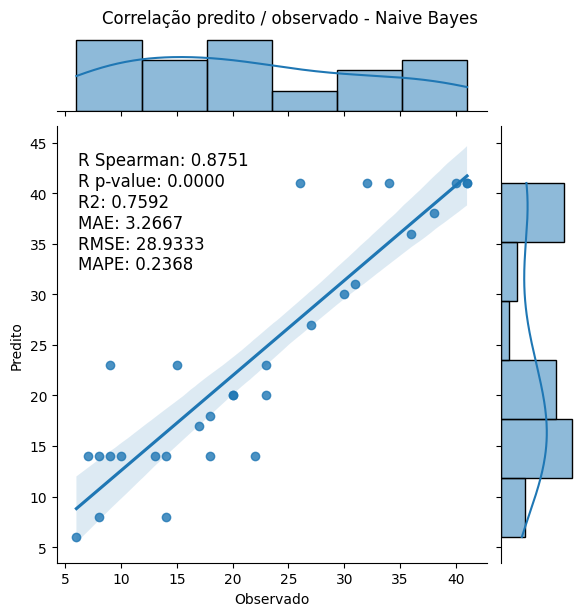

In [44]:
metricas(df_reg_test['target'], df_reg_test['nb'], nome_modelo='Naive Bayes')

In [45]:
df_13['nb'] = nb.predict(df_13[df_13.columns[:c]])
df_13.head()

,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples,linear_multi,svm,nb
53,24.36,1,0,0,0,1,41,41.772154,42.144690,41,41
93,8.05,0,1,0,1,0,9,17.536860,16.687991,9,23
20,19.92,1,0,0,0,1,36,35.174686,35.667611,41,41
177,7.73,1,0,1,0,0,13,17.061367,17.884818,9,17
26,6.21,1,0,1,0,0,17,14.802774,15.667440,18,17


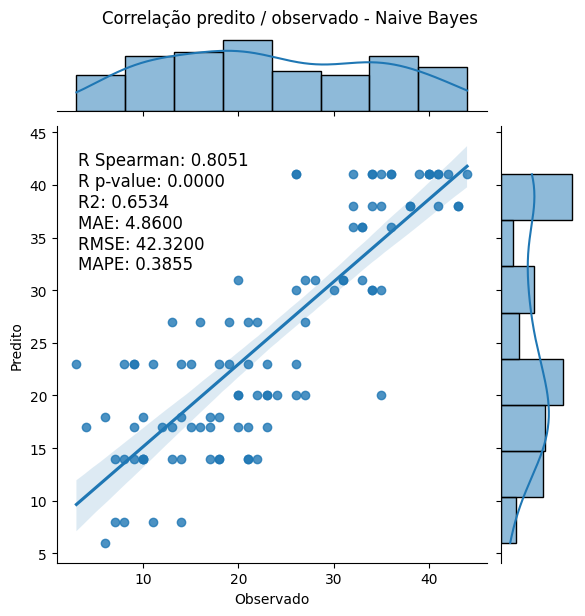

In [46]:
metricas(df_13['target'], df_13['nb'], nome_modelo='Naive Bayes')

In [47]:
dump(df_13, './data/05_aula_df_13')
df_14 = load('./data/05_aula_df_13')

df_14.head()

,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples,linear_multi,svm,nb
53,24.36,1,0,0,0,1,41,41.772154,42.144690,41,41
93,8.05,0,1,0,1,0,9,17.536860,16.687991,9,23
20,19.92,1,0,0,0,1,36,35.174686,35.667611,41,41
177,7.73,1,0,1,0,0,13,17.061367,17.884818,9,17
26,6.21,1,0,1,0,0,17,14.802774,15.667440,18,17


## Redes Neurais

In [48]:
# TensorFlow e tf.keras
import tensorflow as tf
from tensorflow import keras

2025-11-26 19:20:22.586083: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-26 19:20:22.588732: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-26 19:20:22.650510: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-26 19:20:22.651803: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-26 19:20:24.559331: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

In [49]:
df_14_train, df_14_test, X_test, X_train, y_test, y_train = train_test_df_split(df=df_14, indep=indep)

df_train: (70, 11)
df_test: (30, 11)
X_train: (70, 6)
X_test: (30, 6)
y_train: (70,)
y_test: (30,)


In [50]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation='softmax'),
    keras.layers.Dense(32, activation='softmax'),
    keras.layers.Dense(1, activation='linear'),
])

opt = keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer='sgd', # Stochastic Gradient Descent (SGD).
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 6)                 0         
                                                                 
 dense (Dense)               (None, 64)                448       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2,561
Trainable params: 2,561
Non-trainable params: 0
_________________________________________________________________


In [51]:
model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    verbose=0
)

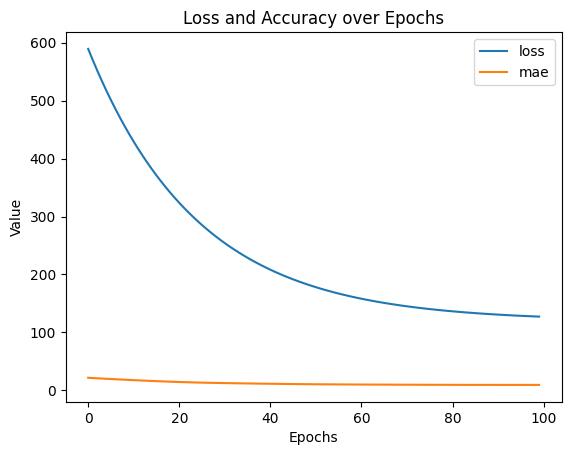

In [52]:
pd.DataFrame(model.history.history).plot(
    title='Loss and Accuracy over Epochs',
    xlabel='Epochs',
    ylabel='Value',
)
plt.show()

In [53]:
c -= 1
df_reg_test['NN'] = model.predict(df_reg_test[df_reg_test.columns[:c]])
df_reg_test.head()

1/1 [==============================] - 0s 68ms/step


,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples,linear_multi,svm,nb,NN
132,5.53,0,1,1,0,0,18,13.792351,12.404122,14,14,18.981339
143,5.61,0,1,1,0,0,14,13.911224,12.520826,14,14,18.981556
121,5.37,0,1,1,0,0,14,13.554604,12.170714,14,8,18.980921
91,7.22,0,1,1,0,0,22,16.303549,14.869497,9,14,18.986967
74,12.19,0,1,0,1,0,20,23.688553,22.727430,20,20,19.012062


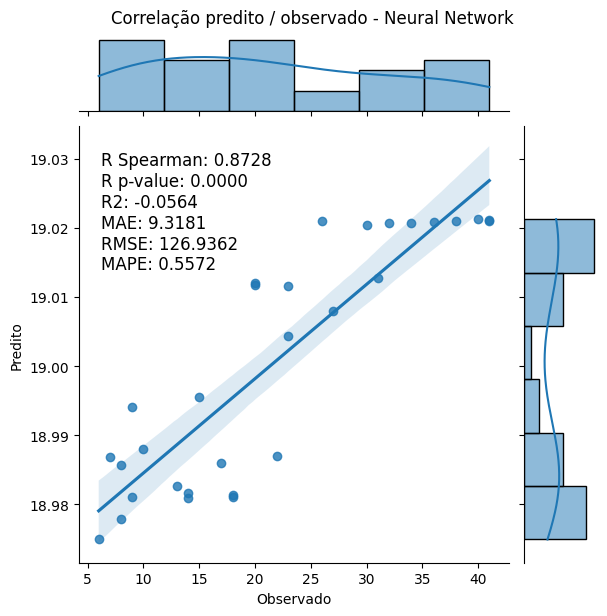

In [54]:
metricas(df_reg_test['target'], df_reg_test['NN'], nome_modelo='Neural Network')

In [55]:
df_14['NN'] = model.predict(df_14[df_14.columns[:c]])
df_14.head()

4/4 [==============================] - 0s 3ms/step


,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples,linear_multi,svm,nb,NN
53,24.36,1,0,0,0,1,41,41.772154,42.144690,41,41,19.021214
93,8.05,0,1,0,1,0,9,17.536860,16.687991,9,23,18.994320
20,19.92,1,0,0,0,1,36,35.174686,35.667611,41,41,19.020813
177,7.73,1,0,1,0,0,13,17.061367,17.884818,9,17,18.992641
26,6.21,1,0,1,0,0,17,14.802774,15.667440,18,17,18.985970


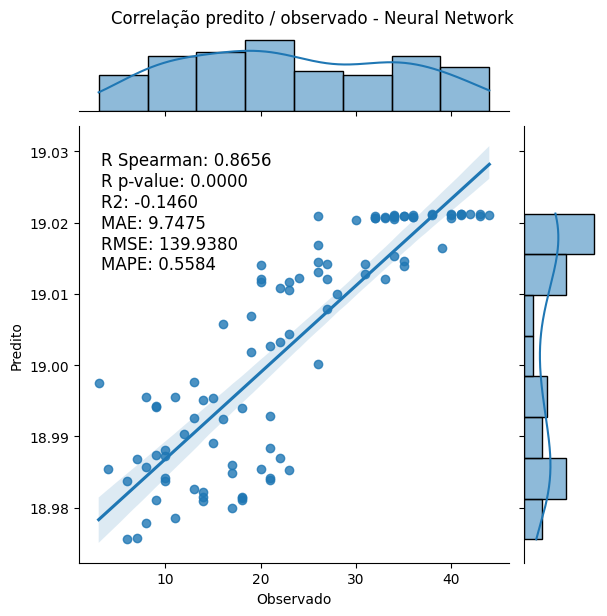

In [56]:
metricas(df_14['target'], df_14['NN'], nome_modelo='Neural Network')

In [57]:
dump(df_14, './data/05_aula_df_14')
df_15 = load('./data/05_aula_df_14')

df_15.head()

,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples,linear_multi,svm,nb,NN
53,24.36,1,0,0,0,1,41,41.772154,42.144690,41,41,19.021214
93,8.05,0,1,0,1,0,9,17.536860,16.687991,9,23,18.994320
20,19.92,1,0,0,0,1,36,35.174686,35.667611,41,41,19.020813
177,7.73,1,0,1,0,0,13,17.061367,17.884818,9,17,18.992641
26,6.21,1,0,1,0,0,17,14.802774,15.667440,18,17,18.985970


## Redes Neurais + GridSearchCV

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier # Se for classificação
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [59]:
df_15_train, df_15_test, X_test, X_train, y_test, y_train = train_test_df_split(df=df_15, indep=indep)

df_train: (70, 12)
df_test: (30, 12)
X_train: (70, 6)
X_test: (30, 6)
y_train: (70,)
y_test: (30,)


In [60]:
# 1. Função de Criação do Modelo
def create_model(optimizer, activation1, activation2):
    model = keras.Sequential([
        keras.layers.Flatten(input_shape=(X_train.shape[1],)),
        keras.layers.Dense(64, activation=activation1),
        keras.layers.Dense(32, activation=activation2),
        keras.layers.Dense(1, activation='linear'),
    ])

    model.compile(
        optimizer=optimizer, # Stochastic Gradient Descent (SGD).
        loss='mse',
        metrics=['mae']
    )
    return model

In [61]:
# 2. Envolvimento do Modelo Keras
# O build_fn aponta para a função que cria o modelo.
# Você também pode fixar hiperparâmetros de treinamento como epochs e batch_size
# dentro de KerasClassifier.
keras_model = KerasClassifier(build_fn=create_model, verbose=0)

In [62]:
# 3. Definição da Grade de Hiperparâmetros
param_grid = {
    'optimizer': ['SGD', 'RMSprop', 'Adam'],
    'epochs': [10, 50], # Hiperparâmetro passado para .fit() do Keras
    'batch_size': [5, 10, 30], # Hiperparâmetro passado para .fit() do Keras
    'activation1': ['relu', 'tanh', 'sigmoid', 'softmax'], # Hiperparâmetro passado para a camada Dense
    'activation2': ['relu', 'tanh', 'sigmoid', 'softmax'], # Hiperparâmetro passado para a camada Dense
}

In [63]:
# Define the EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='loss',  # Monitor validation loss
    mode='min',          # Minimize validation loss
    patience=10,         # Stop after 10 epochs with no improvement
    min_delta=0.001,     # Minimum change to be considered an improvement
    restore_best_weights=True # Restore best weights
)

In [64]:
# 4. Criação e Execução do GridSearchCV
grid = GridSearchCV(estimator=keras_model, param_grid=param_grid, n_jobs=-1, cv=3)

# O gridsearch fará o fit e o cross-validation
grid_result = grid.fit(X_train, y_train, callbacks=[early_stopping])

2025-11-26 19:20:30.733797: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-26 19:20:30.736448: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-26 19:20:30.751740: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-26 19:20:30.754765: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-26 19:20:30.777205: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical re

In [65]:
best_params = grid_result.best_params_
best_params

{'activation1': 'relu',
 'activation2': 'relu',
 'batch_size': 5,
 'epochs': 10,
 'optimizer': 'SGD'}

In [ ]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation=best_params['activation1']),
    keras.layers.Dense(32, activation=best_params['activation2']),
    keras.layers.Dense(1, activation='linear'),
])

model.compile(
    optimizer=best_params['optimizer'], # Stochastic Gradient Descent (SGD).
    loss='mse',
    metrics=['mae']
)
model.fit(
    X_train,
    y_train,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    callbacks=[early_stopping],
    verbose=0
)

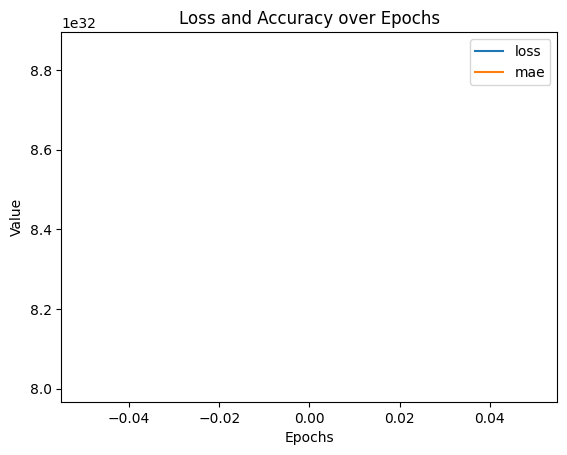

In [75]:
pd.DataFrame(model.history.history).plot(
    title='Loss and Accuracy over Epochs',
    xlabel='Epochs',
    ylabel='Value',
)
plt.show()

In [68]:
c -= 1
df_reg_test['NN-GS'] = model.predict(df_reg_test[df_reg_test.columns[:c]])
df_reg_test.head()

1/1 [==============================] - 0s 55ms/step


,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples,linear_multi,svm,nb,NN,NN-GS
132,5.53,0,1,1,0,0,18,13.792351,12.404122,14,14,18.981339,NaN
143,5.61,0,1,1,0,0,14,13.911224,12.520826,14,14,18.981556,NaN
121,5.37,0,1,1,0,0,14,13.554604,12.170714,14,8,18.980921,NaN
91,7.22,0,1,1,0,0,22,16.303549,14.869497,9,14,18.986967,NaN
74,12.19,0,1,0,1,0,20,23.688553,22.727430,20,20,19.012062,NaN


In [73]:
df_reg_test.dropna().head()

,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples,linear_multi,svm,nb,NN,NN-GS


In [72]:
metricas(df_reg_test['target'], df_reg_test['NN-GS'], nome_modelo='Neural Network')

ValueError: Input contains NaN.

In [70]:
df_14['NN'] = model.predict(df_14[df_14.columns[:c]])
df_14.head()

4/4 [==============================] - 0s 3ms/step


,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,linear_simples,linear_multi,svm,nb,NN
53,24.36,1,0,0,0,1,41,41.772154,42.144690,41,41,NaN
93,8.05,0,1,0,1,0,9,17.536860,16.687991,9,23,NaN
20,19.92,1,0,0,0,1,36,35.174686,35.667611,41,41,NaN
177,7.73,1,0,1,0,0,13,17.061367,17.884818,9,17,NaN
26,6.21,1,0,1,0,0,17,14.802774,15.667440,18,17,NaN
